In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors
import scipy.stats as stats
from scipy import stats
import os
import xarray as xr

In [ ]:
def read_and_regularize(file):

    df = pd.read_csv(file, index_col=False)
    df = df[df.msgtype == 10].drop(columns=['msgtype', 'messages', 'MOMSN', 
                                        'recs','Chain Socket','sensors',
                                        'software', 'H_MeasureTime',
                                        'H_Dutycycle', 'H_Endvolt', 'SN'])

    # rename the "SendTime" column to "time"
    df = df.rename(columns={'SendTime': 'time'})
    df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S').dt.round('15min')
    df = df[~df.duplicated(subset=['time'], keep='first')]
    df = df.set_index('time')

    # define an hour_offset that shifts the time index to start at the nearest 6 hour interval from 00:00:00 to 24:00:00
    hour_offset = (6 - (df.index[0].hour % 6)) % 6
    df.index = df.index + pd.Timedelta(hours=hour_offset)
    df = df.resample('6h', origin='start', offset='00:00:00').bfill()

    # The first timestep is 2025-01-18 06:00:00
    # The last timestep is 2025-07-02 00:00:00
    # Define a date range from 2025-01-18 06:00:00 to 2025-07-02 00:00:00 with a frequency of 6 hours
    date_range = pd.date_range(start='2025-01-18 06:00:00', end='2025-07-02 00:00:00', freq='6h')

    # for any dates in the date_range that are not in the df index, add them and fill with NaN
    df = df.reindex(date_range)
    df = df.fillna(-9999)
    df['num'] = np.arange(len(df))

    # remove the last two sensors (columns)
    df = df.iloc[:, :-2]

    return df

In [ ]:
def initial_surface_from_derivatives(data, first_der, second_der, datamin=10, AirLim=70, SnowLim=70, IceLim=100, dTdzSnow=0.1, temp=6.0, tstep=6, ref_no_days=4): 
	#-------------------------------------------------------------------
    #-------------------------------------------------------------------
    #        
    #  This function approximates the location of the 
    #  material interfaces from the derivative.
    #  
    #  This method to detect the interfaces is not perfoming well (it is noisy), but
    #  it is useful initial guess in the more precised minimation retrieval
    #  algorithm.    
    #
    #  Estimates for the snow and ice layers are are processed independently  
    #-------------------------------------------------------------------

    #-----------------------------------------------
    # Snow layer
    #-----------------------------------------------
		
    a,b = data.shape
    topsnow = np.zeros((a-1,1)) + np.nan
    bottomsnow = np.zeros((a-1,1)) + np.nan
    for k1 in range(0, a-1):
                
        #------------------------------------------------------
        # Find the minimum temperature at the top of the chain
        #------------------------------------------------------
        # We find the indice of the minimum temperature, 
        # assuming that the snow layer is below this point
                
        # Note that Here, we skip the 10 top sensors (20 cm) 
        # and assume that the snow syrface is <140cm away... 
         # Needs improvement
                
        data_time_k = data[k1,datamin:AirLim]
        airTmin = np.amin(data_time_k)
                
        start_ind = np.argmin(data_time_k)+datamin

        # If the air temperature is too high, there is no gradient
        # and we skip the computations
        if ((airTmin < -temp) and (np.isnan(airTmin)==0)):
                    
           #-----------------------------------------------
            # Find the position of air-snow interface
            #-----------------------------------------------
                        
            #The maximum derivative ~ middle of the snow layer
            TopChainDeriv = first_der[k1,start_ind:SnowLim]
            midsnow_loc = np.argmax(TopChainDeriv)+start_ind
          
            #find the top of the snow as the nearest point above
            # the largest slope with 
            # a gradient <0.1 (self.dTdzSnow)
            TopChainDeriv = first_der[k1,0:midsnow_loc]
            N = len(TopChainDeriv)
            indices = np.arange(N)
            condition = indices[TopChainDeriv<dTdzSnow]
            N = len(condition)   
            if N == 0:
                print("No snow detected!!!!")
            else:    
                highest_snow_sensor = np.nanmax(condition)
                topsnow[k1] = highest_snow_sensor
        
                #-----------------------------------------------
                # Find the position of snow - ice interface
                #-----------------------------------------------
         
                #Method: assuming that the interface is at the largest curvature point.
                MaxLim = IceLim #we are spanning wider
                SnowLayerInflection = second_der[k1,int(topsnow[k1]+1):MaxLim]
                lowest_snow_sensor = np.argmin(SnowLayerInflection)+int(topsnow[k1]+1)
                            
                bottomsnow[k1] = lowest_snow_sensor
        
    # Interpolating to fill the gaps in data...
    bot_snow_int = interp_data(np.squeeze(bottomsnow))
    
    Zice0, dummy = stats.mode(bot_snow_int[0:int((24.0/tstep)*ref_no_days)])
    Zice0 = int(Zice0)

    return Zice0
 

def interp_data(data):
    a = len(data)
    val_interp = data.copy()
    val_dum = np.arange(a)
    val_nan = val_dum[np.isnan(data)==1]
    val_1 = val_dum[np.isnan(data)==0]
    for k_nan in range(0, len(val_nan)):
        for k_1 in range(0, len(val_1)-1):
            if ( val_1[k_1]<val_nan[k_nan]) and ( val_1[k_1+1]>val_nan[k_nan]):
                indL = val_1[k_1]
                indR = val_1[k_1+1]
                val_interp[int(val_nan[k_nan])] = data[indL] + (val_nan[k_nan]-indL)*(data[indR]- data[indL])/(indR-indL)
    return val_interp


def compute_derivatives(data, nsensors=240):
    #-------------------------------------------------------------------
    #-------------------------------------------------------------------     
    #  This function computes the first and second vertical derivatives
    #  of the temperature data.
    #  
    #  This method to detect the interfaces is not perfoming well, but
    #  it is useful to determine the location of the "thermistor string
    #  plateau" in the SAMS buoy, and the initial snow-ice interface in
    #  any buoy, which is needed in the more robust minimation retrieval
    #  algorithm .      
    #-------------------------------------------------------------------

    a,b = data.shape
    first_der = np.zeros((a, nsensors+1)) + np.nan
    second_der = np.zeros((a, nsensors+1)) + np.nan
            
    #----------------------------------------
    # Set vertical profile (sensor positions)
    #----------------------------------------
    z = np.zeros((nsensors+1,1))
    for k in range(1, nsensors+1):
        z[k] = k*-2.0
    zf = len(z)
  
  
    #----------------------------------------
    # Calculate derivatives
    #----------------------------------------
  
    for k1 in range(0, a-1):
  
        # Compute the derivative (center difference)
        for kz in range(1, zf-2):
            first_der[k1,kz] = (data[k1,kz+1] - data[k1,kz-1])/4.0
      
        # Compute the second derivative (center difference)
        for kz in range(1, zf-2):
            second_der[k1,kz] = (first_der[k1,kz+1] - first_der[k1,kz-1])/4.0

    return first_der, second_der


def compute_interfaces(data, tstep=6, datamin=10, nsensors=240, dTdzSnow=0.1, dtemp=5.0, dtemp_i=1.0, init_time=2, ref_no_days=2):
    #-------------------------------------------------------------------
    #-------------------------------------------------------------------
    #        GET THE SNOW AND ICE INTERFACE: FROM MINIMATION
    #        
    #  This function finds the position of the material interfaces by the
    #  minimation of error functions on a theoretical temperature 
    #  profile.
    #  
    #  The vertical profiles are described by the following points to 
    #  be retrieved:
    #  
    #  Z1, T1 : Position and temperature of the air-snow interface
    #  Z2, T2 : Position and temperature of the snow-ice surface
    #  Zice0, Tice0 : Original ice surface (at deployment) 
    #  Zp, Tp : Other end of surface plateau (SAMS buoys)
    #  Zc, Tc : Sensor located inside the ice
    #  Zio, Tio : Position and temperature of the ice-ocean interface
    #-------------------------------------------------------------------

    data = data.values
    KDAYS = []
    K_4DAYS = []

    # Start by computing derivatives
    a,b = data.shape
    first_der, second_der = compute_derivatives(data, nsensors=nsensors)

    # Initialize arrays to store the interface positions and temperatures
    Z_as_minim = np.zeros((a,1))   # Air-snow interface
    Z_si_minim = np.zeros((a,1))   # Snow-ice interface
    Z_io_minim = np.zeros((a,1))   # Ice-ocean interface
    Z_ice_surf = np.zeros((a,1)) 
    Tbottom = np.zeros((a,1)) + np.nan
    bottom_init = 0.0

    # Find the initial ice surface position
    # Zice0 = find_initial_ice_surface(data, first_der, second_der)
    Zice0 = initial_surface_from_derivatives(data, first_der, second_der,ref_no_days=ref_no_days)
    Z_ice_surf = Z_ice_surf + Zice0
    Zice_surf_prev = Zice0
    # Initialized previous itterate memory terms used later in the algo.
    Tice0_prev = -3.0
    Zice0_prev = int(Zice0)
    Zsi_init = int(Zice0)
    Tminim0 = 1
    Tmin_prev = -3.0
    kyesterday = 0

    # Start looping over the profiles
    for k1 in range(0, int(a)):

        # Initialize the interface locations as nans
        Z_as_minim[k1] = np.nan
        Z_si_minim[k1] = np.nan
        Z_io_minim[k1] = np.nan

        # sort 4 days intervals for verification
        # kday is the index of the start of the current "day" period (capped at the last index)
        kday = int(np.min([int(k1*tstep/24),int(a*tstep/24)-1]))
        KDAYS.append(kday)
        # k_4days is the index of the start of a four-day period ending in kday (capped at the first index)
        k_4days = np.max([0, (kday-4)*int(24/tstep)])
        K_4DAYS.append(k_4days)
        # find the time with the coldest temperature
        k_night = np.nanmin([int(kday*(24/tstep) + init_time), int(a)])
        Tmin_init = -3.0
        for deltak in range(int(-24/(tstep*4)), int(24/(tstep*4)+1)):
            Tmin = np.nanmin(data[int(k_night + deltak),
                                  datamin:int(nsensors-10)])
            if (Tmin < Tmin_init):
                k_minTemp = k_night + deltak
                Tmin_init = Tmin
            else:
                k_minTemp=k_night
        k_night = int(k_minTemp)    

        if (np.isnan(data[k1,2])):
                #Skip rows with invalid data
                print('NaN at k1 = ', k1)
        else: 
            #-------------------------------------
            # INITIALIZING:
            # Defining initial reference points in the profiles
            # 
            # Get the temperature at the reference pts (Tmin,Tice0,Tp,Tocean)
            #-------------------------------------

            # Position and temperature of lowest temperature in profile. Used as initial guess                
            Tmin= np.nanmin(data[k1,datamin:nsensors-10])
            Zmin = np.argmin((data[k1,datamin:nsensors-10]-Tmin)**2.0)+datamin
                
            # Air temperature
            Tair = np.mean(data[k1,datamin:datamin+5])
            
            # Ocean temperature.
            Tocean_mode, dummy = stats.mode(data[k1,nsensors-20:nsensors-5])
      
            # Initial ice surface temperature
            Tice0 = data[k1,Zice0]
                
            # Tc: A random point in the ice: with a temperature between Tb and Tocean. 
            # Set to 1/3rd of the temperature difference so that we are closer to 
            # the ice bottom.
            Tc = np.max([(Tice0-Tocean_mode)/3.0 + Tocean_mode, -5.0])
            Zc = int(np.argmin((data[k1,Zice0:nsensors-10]-Tc)**2.0))+Zice0
            Tc = data[k1,Zc]
    
            # Re-initialise profile ice temperature gradient 
            beta_ice = 0.0
            Tanalytic_rec = np.zeros((nsensors+1,1)) + np.nan

            #------------------------------------------------------------
            # 0. Identify flooding events
            #       - based on temperature between Zmin and Zice0
            #------------------------------------------------------------

            # set up
            flood_bound = -3
            lB = int(Z_ice_surf[k1])
            if (k1 == 0) | (np.isnan(Z_as_minim[k1])):
                uB = Zice0 - 15
            else:
                uB = Z_as_minim[k1]

            # check the temperature profile
            flooded_layer = data[k1, uB:lB]
            # print(Tocean_mode)
            if (np.max(flooded_layer) > flood_bound) & (np.max(flooded_layer) <= 0):
                print('founded a flooded layer! k1 is ', k1)
                loc_flood_surf = int(np.argmax(flooded_layer) + uB) 
                print('index of flooded surface is', loc_flood_surf)
                if (loc_flood_surf > (Zice0-15)) & (loc_flood_surf < Zice_surf_prev) & (loc_flood_surf > Tmin):
                    Z_ice_surf[k1:] = loc_flood_surf
                    Zice_surf_prev = loc_flood_surf
    
            Zice1 = int(Z_ice_surf[k1])
            Tice1 = data[k1, Zice1]

            # Condition to continue: negative gradients in snow and ice
            if ((Zmin <= Zice1) & (Zc>Zice1)):    					      
                #-----------------------------------------------------------------
                # 1. ICE BOTTOM: Found by minimizing about the bottom kink
                #
                #  Here, we make 20 test theoretical profiles, each with ice-ocean 
                #  interface set at a given sensor position. The real 
                #  interface is then set based on the profile that
                #  minimes the error on a piece-wise linear profile.
                #
                #  We only scan from the sensor where T=-2.2C. 
                #  This is to reduce computation cost while making sure 
                #  that we start above the interface, but close to it. 
                #-----------------------------------------------------------------
                    
                # Condition to continue: minimum deltaT in ice
                if ((Tice1 < Tocean_mode - dtemp_i)):
						
                    # Initializng the theoretical profile:
                    Zio_init = int(np.argmin((data[k1,Zice1:nsensors-10]+2.2)**2.0))+Zice1
                    Tio_init = data[k1,Zio_init]
                    Tanalytic_rec = np.zeros((nsensors+1,1)) + np.nan
                    Err_min = 9999.0
                        
                    # Scan the sensors to find theoretical profile that best match the obs. 
                    for dz in range(-10,10):
                            
                        # Re-initialise the theoretical profiles
                        Tanalytic = np.zeros((nsensors+1,1)) + np.nan   #reset the piece-wise linear profile
                        Zio_Test = np.nanmax([Zc,Zio_init + dz])     #Test sensor position, limited to below Zc
                        Tio_Test = Tocean_mode                       
                        beta_ice_test = (Tio_Test-Tc)/(Zio_Test-Zc)  # temperature slope based on Tc and the test position

                        # Compute the error between the test profile and the real obs:
                        Err = 0.0
                        for kz in range(int(Zio_Test-10),int(np.nanmin([Zio_Test+10, nsensors-10]))):
                            if (kz <= Zio_Test):
                                Tanalytic[kz] = beta_ice_test*(kz-Zc) + Tc
                                Err = Err + (Tanalytic[kz] - data[k1,kz])**2.0
                            else :
                                Tanalytic[kz] = Tio_Test
                                Err = Err + (Tanalytic[kz] - data[k1,kz])**2.0
                                    
                        #Record the position and temperature if the error is smaller than previous iterates        
                        if (Err < Err_min):
                            Err_min = Err
                            Zio = Zio_Test
                            Tio = Tio_Test
                            beta_ice = beta_ice_test
                            Tanalytic_rec = Tanalytic
                        # else:
                        #     print('Err < Err_min not met at k1=', k1, ' dz=', dz, ' Err=', Err, ' Err_min=', Err_min)
    
             
                    Z_io_minim[k1] = Zio
                    Tbottom[k1] = data[k1,Zio]
                        
                    #Record the first trustworthy bottom ice position (after 4 days, so that the hole is refrozen)
                    if bottom_init == 0 and k1>15:
                        bottom_init = Zio
                        
            #------------------------------------------------------------
            # 2. Air-snow interface.
            #      as the highest point where grad-T exceeds that in the ice
            #
            # We move the air-snow interface to test location if:
            #   - The inflection is largest
            #   - The slope in snow below is larger than a set threshold
            #   - The slope in air above is smaller then threshold*2
            # 
            #------------------------------------------------------------

            # Conditions to continue:  
            #  - minimum deltaT in the snow, for at least 6h,
			#  - no temperature gradient reversal in snow (piecewise linear assumption)	 
			# This is added to filter rare cases under rapid cooling weather, 
			# when the air temperature conditions is met
			# but the snow layer remains warmer than the ice below
                if Zmin == Zice0:
                    Tmax = data[k1, Zmin]
                else:
                    Tmax = np.max(data[k1,Zmin:Zice0])
                if (((Tmin < Tice1 - dtemp) & 
                     (Tmin_prev < Tice0_prev - dtemp)) & 
                     ((Tmax < Tice0+0.25) & (Tair <= Tice1))):

					#re-initialise parameters for new profile
                    Curv_init = 0.0
                    Zas = Zmin     #Initial guess: snow top is where Tmin is.
            
                    #Span from Tmin to the original ice surface to test if it is the interface
                    for z_test in range(Zmin,int(Zice1)):
							
						#Temperature at test location
                        Tas_test = data[k1,z_test]
                            
                        #slope over 8cm
                        T_above = data[k1,z_test-2]
                        T_below = data[k1,z_test+2]
                        beta_snow = (T_below-T_above)/2
                        #slope over 4cm above and below the test location
                        beta_snow_above = (Tas_test-T_above)/(-4.0)
                        beta_snow_below = (T_below-Tas_test)/(-4.0)
                        
                        #Curvature over 8cm
                        Curv =(T_below-2.0*Tas_test+T_above)/(2.0)
                        
                        # Determining if the location is the interface
                        if (Curv > Curv_init) & (-beta_snow_below > dTdzSnow) & (-beta_snow_above < dTdzSnow*2.0):
                            Zas = int(np.nanmax([z_test,Zas]))
                            Tas = data[k1,Zas]
                            beta_snow = (Tas-Tice1)/(Zas-Zice1)
                            Curv_init = Curv
                            for kz in range(Zas,Zice1):
                                Tanalytic_rec[kz] =  Tas + beta_snow*(kz-Zas)

                #------------------------------------------------------------
                # 3. Snow-ice (flooding)
                #       - based on where the slope exceeds that in the ice
                #------------------------------------------------------------
        
                    #Initializing
                        
                    beta_snow = (Tas-Tice1)/(Zas-Zice1)
                    beta_diff = beta_snow  - beta_ice
                    Zsi = Zas
                    Zsi_high = Zas
                    Zsi_low = Zas
                        
                    # Find interval with slopes between snow and ice
                    Zice1 = int(Z_ice_surf[k1])
                    for Zsi_test in range(int(Zas+1),Zice1+1):
							
                        #Get the temperatures and gradients about the test position
                        Tsi_test = data[k1,Zsi_test]
                        T_above = data[k1,Zsi_test-1]
                        T_below = data[k1,Zsi_test+1]
                        beta_above = (Tsi_test-T_above)/(2.0)
                        beta_below = (T_below-Tsi_test)/(2.0)
                        beta_test = (T_below-T_above)/(2.0)
                        
                        #Find the lowest position with a gradient close to that in snow
                        if ((beta_test > beta_snow - beta_diff*0.2)):
                            Zsi_high = np.nanmax([Zsi_high, Zsi_test])
                        #Find the lowest position with slope larger than in the ice
                        if ((beta_test > beta_snow - beta_diff*0.8)):
                            Zsi_low = np.nanmax([Zsi_low, Zsi_test])
                        
                    #Define the interface by the point with largest curvature
                    Curv_si_init = 0.0
                    Zsi = Zsi_high
                    for z_test in range(Zsi_high,Zsi_low+2):
                        #Compute curvature at point
                        T_above = data[k1,z_test-2]
                        T_test = data[k1,z_test]
                        T_below = data[k1,z_test+2]
                        Curv_si =(T_below-2.0*T_test+T_above)/(2.0)
          
                        if (Curv_si < Curv_si_init):
                            Zsi = np.nanmax([Zsi,z_test])
                            Curv_si_init = Curv_si 
                                
                    Zsi = np.min([Zsi,Zice1])   
                    Zsi_prev = np.min([Zsi,Zice1])        
                    Tsi = data[k1,Zsi]
                   
                    # We only accept snow-ice if it does not get back down in the following 4 days.
                    # I.e., reset the interface if it is not permanent
                    # kyesterday is the index of the start of the day period
                    # kyesterday = kday*int(24/tstep)
                    # if we are at the start of the day period
                    if kyesterday == k1:
                        # reassign 
                        kyesterday = int(np.max([0,(kday-1)*int(24/tstep)]))
                    
                    # if the minimum index of the snowice interface between yesterday and today is less than the previous Zsi index
                    # then the amount of snow ice has increased. If this is true and the index of current snow ice is less than or equal to Zice0
                    # if ((np.nanmin(Z_si_minim[kyesterday:k1]) > Zsi_prev) & (Zsi <= Zice1)):
                    if ((np.nanmin(Z_si_minim[kyesterday:k1]) > Zsi_prev) & (Zsi <= Zice1)):
                        # assign the previous 4 days of snow ice calculations to an interval variable
                        interval_4day = Z_si_minim[k_4days:k1]
                        # Where the snow ice interface is higher than the previous Zsi, assign it to be the previous Zsi
                        interval_4day[Z_si_minim[k_4days:k1] > Zsi_prev] = Zsi_prev
                        Z_si_minim[k_4days:k1] = interval_4day


            #-----------------------------------------------------------------
            # End of retrival.
            # Writing results in diagnostic time-series
            #-----------------------------------------------------------------

                    Z_as_minim[k1] = Zas
                    Z_si_minim[k1] = Zsi
                    # snowthick_minim[k1] = (Zsi - Zas)*2.0

                    Z_io_minim[k1] = Zio
                    # icethick_minim[k1] = (Zio - Zice0)*2.0 + (Zice0 - Zsi)*2.0
                        
    
            # Update the history parameters
            if k1 == k_night:
                Tmin_prev = Tmin
                Tice0_prev = Tice0 
                kyesterday = k_night    

    #-----------------------------------------------------------------
    #  Mask data in the arrays and perform daily running means
    #-----------------------------------------------------------------

    Zsi_og = Z_si_minim.copy()
    # prepare mask to hide points in th running means 
    Z_as_tmp = Z_as_minim.copy()
    Z_si_tmp = Z_si_minim.copy()
    Z_io_tmp = Z_io_minim.copy()
    Z_ice_surf_tmp = Z_ice_surf.copy()

    Z_as_tmp2 = Z_as_minim.copy()
    Z_si_tmp2 = Z_si_minim.copy()
    Z_io_tmp2 = Z_io_minim.copy()
    Z_ice_surf_tmp2 = Z_ice_surf.copy()

    Z_as_tmp3 = Z_as_minim.copy()
    Z_si_tmp3 = Z_si_minim.copy()
    Z_io_tmp3 = Z_io_minim.copy()
    Z_ice_surf_tmp3 = Z_ice_surf.copy()

    Z_as_tmp[1:-1] = ~np.isnan(Z_as_minim[0:-2]) + ~np.isnan(Z_as_minim[1:-1]) + ~np.isnan(Z_as_minim[2:])
    Z_si_tmp[1:-1] = ~np.isnan(Z_si_minim[0:-2]) + ~np.isnan(Z_si_minim[1:-1]) + ~np.isnan(Z_si_minim[2:])
    Z_io_tmp[1:-1] = ~np.isnan(Z_io_minim[0:-2]) + ~np.isnan(Z_io_minim[1:-1]) + ~np.isnan(Z_io_minim[2:])
    Z_ice_surf_tmp[1:-1] = ~np.isnan(Z_ice_surf_tmp[0:-2]) + ~np.isnan(Z_ice_surf_tmp[1:-1]) + ~np.isnan(Z_ice_surf_tmp[2:])
    
    Z_as_tmp2[0:-2] = ~np.isnan(Z_as_minim[0:-2]) + ~np.isnan(Z_as_minim[1:-1]) + ~np.isnan(Z_as_minim[2:])
    Z_si_tmp2[0:-2] = ~np.isnan(Z_si_minim[0:-2]) + ~np.isnan(Z_si_minim[1:-1]) + ~np.isnan(Z_si_minim[2:])
    Z_io_tmp2[0:-2] = ~np.isnan(Z_io_minim[0:-2]) + ~np.isnan(Z_io_minim[1:-1]) + ~np.isnan(Z_io_minim[2:])
    Z_ice_surf_tmp2[0:-2] = ~np.isnan(Z_ice_surf_tmp2[0:-2]) + ~np.isnan(Z_ice_surf_tmp2[1:-1]) + ~np.isnan(Z_ice_surf_tmp2[2:])

    Z_as_tmp3[2:] = ~np.isnan(Z_as_minim[0:-2]) + ~np.isnan(Z_as_minim[1:-1]) + ~np.isnan(Z_as_minim[2:])
    Z_si_tmp3[2:] = ~np.isnan(Z_si_minim[0:-2]) + ~np.isnan(Z_si_minim[1:-1]) + ~np.isnan(Z_si_minim[2:])
    Z_io_tmp3[2:] = ~np.isnan(Z_io_minim[0:-2]) + ~np.isnan(Z_io_minim[1:-1]) + ~np.isnan(Z_io_minim[2:])
    Z_ice_surf_tmp3[2:] = ~np.isnan(Z_ice_surf_tmp3[0:-2]) + ~np.isnan(Z_ice_surf_tmp3[1:-1]) + ~np.isnan(Z_ice_surf_tmp3[2:])

    # transform to daily means
    Z_as_minim[2:-1] = np.nanmean([Z_as_minim[0:-3], Z_as_minim[1:-2], Z_as_minim[2:-1], Z_as_minim[3:]], 0)
    Z_si_minim[2:-1] = np.nanmean([Z_si_minim[0:-3], Z_si_minim[1:-2], Z_si_minim[2:-1], Z_si_minim[3:]], 0)
    Z_io_minim[2:-1] = np.nanmean([Z_io_minim[0:-3], Z_io_minim[1:-2], Z_io_minim[2:-1], Z_io_minim[3:]], 0)
    Z_ice_surf[2:-1] = np.nanmean([Z_ice_surf[0:-3], Z_ice_surf[1:-2], Z_ice_surf[2:-1], Z_ice_surf[3:]], 0)

    # apply the mask
    Z_as_minim[Z_as_tmp[:]==False] = np.nan
    Z_si_minim[Z_si_tmp[:]==False] = np.nan     
    Z_io_minim[Z_io_tmp[:]==False] = np.nan   
    Z_as_minim[Z_as_tmp2[:]==False] = np.nan
    Z_si_minim[Z_si_tmp2[:]==False] = np.nan     
    Z_io_minim[Z_io_tmp2[:]==False] = np.nan   
    Z_as_minim[Z_as_tmp3[:]==False] = np.nan
    Z_si_minim[Z_si_tmp3[:]==False] = np.nan     
    Z_io_minim[Z_io_tmp3[:]==False] = np.nan  

    # generate ice thickness and snow thickness timeseries
    # ice_thickness = (Z_io_minim - Zice0)*2.0 + (Zice0 - Z_si_minim)*2.0
    ice_thickness = (Z_io_minim - Z_ice_surf)*2.0 #+ (Z_ice_surf - Z_si_minim)*2.0b
    # snow_thickness = (Z_si_minim - Z_as_minim)*2.0
    snow_thickness = (Z_ice_surf - Z_as_minim)*2.0

    return Z_as_minim, Z_si_minim, Z_io_minim, Z_ice_surf, Zice0, ice_thickness, snow_thickness, first_der, Zsi_og

In [4]:
def get_ice_temperature_profile(data, Zis, Zio):
    temp_profiles_from_ice_surface = np.zeros((np.shape(data)[0], 150)) + np.nan
    for k in range(0, np.shape(data)[0]):
        if ~np.isnan(Zis[k]) & ~np.isnan(Zio[k]):
            ice_temp_profile = data.values[k, int(Zis[k]):int(Zio[k])]
            if len(ice_temp_profile) > 0:
                temp_profiles_from_ice_surface[k, :len(ice_temp_profile)] = ice_temp_profile
                
    return temp_profiles_from_ice_surface

In [5]:
def write_retrieval_output(output_tag, thickness, snowdepth, temp_profiles_from_ice_surface, time, location):

    lat = [location[0]]
    lon = [location[1]]
    output_filename = output_tag + '_retrievals.nc'

    ds = xr.Dataset(data_vars = dict(Ice_Thickness=(['time', 'loc'], thickness),
                                     Snow_Depth=(['time', 'loc'], snowdepth),
                                     Temp_Profile=(['time', 'sensor'], temp_profiles_from_ice_surface)
                                     ),
                    coords = dict(lat=('loc',lat), lon=('loc',lon), 
                                  time=time, 
                                  sensor=range(len(temp_profiles_from_ice_surface[0]))),
                    attrs = dict(description= "Ice thickness retreivals from SIMBA instruments in "+output_tag+". Data has been standardized in time to 15 min intervals and then interpolated to 6-hourly timesteps.")
                    )
    
    ds.to_netcdf(output_filename)
    # time.sleep(2)

    if os.path.exists(output_filename):
        check = 0
    else:
        check = 1
    return check

In [6]:
def remove_year_hour_minute_second(times):
    return [time.strftime('%m-%d') for time in times]

## Cambridge Bay

In [ ]:
# Flooded sites
data_path = '/Users/mollyw/Desktop/ARISE-AIM/Data/raw/RealIce/ice'

# read csv file swith pandas
file = data_path + '/realice0103.csv'
data4 = read_and_regularize(file)

file = data_path + '/realice0102.csv'
data3 = read_and_regularize(file)

file = data_path + '/realice0105.csv'
data7 = read_and_regularize(file)

# fill in missing values for data7 at index 19 and 243 with the mean of their neighboring rows
data7.iloc[19] = np.mean([data7.iloc[18], data7.iloc[20]], axis=0)
data7.iloc[243] = np.mean([data7.iloc[242], data7.iloc[244]], axis=0)

In [ ]:
# Control sites

# read csv file with pandas
file = data_path + '/realice0104.csv'
datac1 = read_and_regularize(file)
datac1 = datac1.iloc[:95] #28

# bring in data from the 0102 SIMBA, which was moved to a control site mid-season
datac2 = data3[466:].copy()
datac = pd.concat([datac1, datac2], axis=0)
date_range = pd.date_range(start='2025-01-18 06:00:00', end='2025-07-02 00:00:00', freq='6h')
datac = datac.reindex(date_range, fill_value=-9999)

# replace the end of the data3 time series with NaN values to match the length of the other datasets
data3[326:] = np.nan

In [ ]:
# compute interfaces for control sites.
Z_asc1, Z_sic1, Z_ioc1, Z_isc1, Zice0c1, hic1, hsc1, first_derc1, Zsi_ogc1 = compute_interfaces(datac1[28:], ref_no_days=7)
Z_asc2, Z_sic2, Z_ioc2, Z_isc2, Zice0c2, hic2, hsc2, first_derc2, Zsi_ogc2 = compute_interfaces(datac2.fillna(-9999), ref_no_days=3)
Z_asc, Z_sic, Z_ioc, Z_isc, Zice0c, hic, hsc, first_derc, Zsi_ogc = compute_interfaces(datac)

founded a flooded layer! k1 is  1
index of flooded surface is 51
founded a flooded layer! k1 is  2
index of flooded surface is 50
founded a flooded layer! k1 is  3
index of flooded surface is 49
founded a flooded layer! k1 is  22
index of flooded surface is 37
founded a flooded layer! k1 is  23
index of flooded surface is 37
founded a flooded layer! k1 is  24
index of flooded surface is 37
founded a flooded layer! k1 is  25
index of flooded surface is 37
founded a flooded layer! k1 is  26
index of flooded surface is 37
founded a flooded layer! k1 is  27
index of flooded surface is 37
founded a flooded layer! k1 is  28
index of flooded surface is 37
founded a flooded layer! k1 is  29
index of flooded surface is 37
founded a flooded layer! k1 is  30
index of flooded surface is 37
founded a flooded layer! k1 is  31
index of flooded surface is 37
founded a flooded layer! k1 is  59
index of flooded surface is 45
founded a flooded layer! k1 is  71
index of flooded surface is 37
founded a flo

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SnowLayerInflection = second_der[k1,int(topsnow[k1]+1):MaxLim]
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lowest_snow_sensor = np.argmin(SnowLayerInflection)+int(topsnow[k1]+1)
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:262: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before p

In [ ]:
# compute interfaces for flooded sites.
Z_as3, Z_si3, Z_io3, Z_is3, Zice03, hi3, hs3, first_der3, Zsi_og3 = compute_interfaces(data3, ref_no_days=14)
Z_as4, Z_si4, Z_io4, Z_is4, Zice04, hi4, hs4, first_der4, Zsi_og4 = compute_interfaces(data4)
Z_as7, Z_si7, Z_io7, Z_is7, Zice07, hi7, hs7, first_der7, Zsi_og7 = compute_interfaces(data7)

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SnowLayerInflection = second_der[k1,int(topsnow[k1]+1):MaxLim]
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lowest_snow_sensor = np.argmin(SnowLayerInflection)+int(topsnow[k1]+1)
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:262: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before p

founded a flooded layer! k1 is  466
index of flooded surface is 55
founded a flooded layer! k1 is  467
index of flooded surface is 52
founded a flooded layer! k1 is  468
index of flooded surface is 51
founded a flooded layer! k1 is  469
index of flooded surface is 50
founded a flooded layer! k1 is  470
index of flooded surface is 49
founded a flooded layer! k1 is  495
index of flooded surface is 41
founded a flooded layer! k1 is  496
index of flooded surface is 41
founded a flooded layer! k1 is  497
index of flooded surface is 41
founded a flooded layer! k1 is  498
index of flooded surface is 41
founded a flooded layer! k1 is  500
index of flooded surface is 41
founded a flooded layer! k1 is  501
index of flooded surface is 41
founded a flooded layer! k1 is  509
index of flooded surface is 41
founded a flooded layer! k1 is  525
index of flooded surface is 45
founded a flooded layer! k1 is  537
index of flooded surface is 41
founded a flooded layer! k1 is  548
index of flooded surface i

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:524: RuntimeWarning: Mean of empty slice
  Z_as_minim[2:-1] = np.nanmean([Z_as_minim[0:-3], Z_as_minim[1:-2], Z_as_minim[2:-1], Z_as_minim[3:]], 0)
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:525: RuntimeWarning: Mean of empty slice
  Z_si_minim[2:-1] = np.nanmean([Z_si_minim[0:-3], Z_si_minim[1:-2], Z_si_minim[2:-1], Z_si_minim[3:]], 0)
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1444451070.py:526: RuntimeWarning: Mean of empty slice
  Z_io_minim[2:-1] = np.nanmean([Z_io_minim[0:-3], Z_io_minim[1:-2], Z_io_minim[2:-1], Z_io_minim[3:]], 0)


founded a flooded layer! k1 is  496
index of flooded surface is 58
founded a flooded layer! k1 is  497
index of flooded surface is 58
founded a flooded layer! k1 is  498
index of flooded surface is 58
founded a flooded layer! k1 is  499
index of flooded surface is 58
founded a flooded layer! k1 is  500
index of flooded surface is 58
founded a flooded layer! k1 is  501
index of flooded surface is 58
founded a flooded layer! k1 is  502
index of flooded surface is 58
founded a flooded layer! k1 is  508
index of flooded surface is 58
founded a flooded layer! k1 is  509
index of flooded surface is 58
founded a flooded layer! k1 is  510
index of flooded surface is 58
founded a flooded layer! k1 is  512
index of flooded surface is 58
founded a flooded layer! k1 is  513
index of flooded surface is 58
founded a flooded layer! k1 is  516
index of flooded surface is 58
founded a flooded layer! k1 is  517
index of flooded surface is 58
founded a flooded layer! k1 is  520
index of flooded surface i

In [ ]:
# compute temperature profiles for sea ice 
temp_profilec = get_ice_temperature_profile(datac, Z_isc, Z_ioc)
temp_profile3 = get_ice_temperature_profile(data3, Z_is3, Z_io3)
temp_profile4 = get_ice_temperature_profile(data4, Z_is4, Z_io4)
temp_profile7 = get_ice_temperature_profile(data7, Z_is7, Z_io7)

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_64973/1346670581.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ice_temp_profile = data.values[k, int(Zis[k]):int(Zio[k])]


### Plot SIMBA Data

In [ ]:
# do data trimming for plots

datac.iloc[:28] = np.nan
datac.iloc[95:467] = np.nan

data3.iloc[:4] = np.nan
data4.iloc[:4] = np.nan
data7.iloc[:4] = np.nan

datac = datac[4:]
data3 = data3[4:]
data4 = data4[4:]
data7 = data7[4:]

# assign x-ticks for plotting
xticks1 = np.arange(0, len(data3), 75)[0:5]
xticks2 = np.arange(0, len(data3), 75)[5:] - len(data3)/2

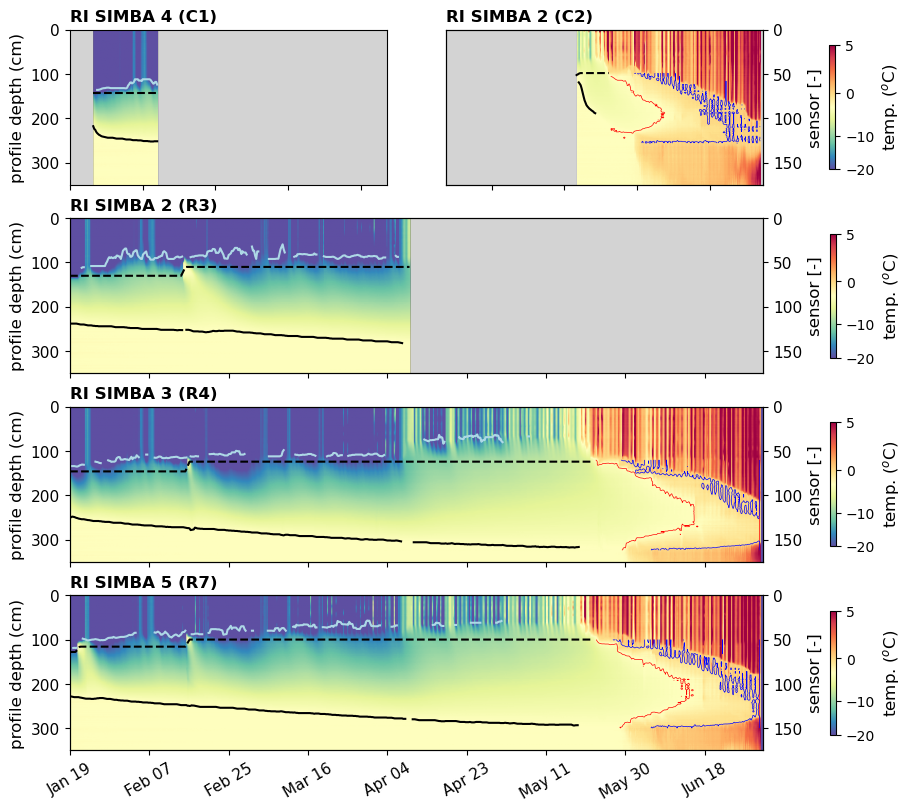

In [ ]:
fig = plt.figure(layout='constrained', figsize=(9, 8)) #, layout='constrained')
axes = fig.subplot_mosaic([['TopLeft', 'TopRight'],['Middle1', 'Middle1'], ['Middle2','Middle2'],['Bottom','Bottom']],
                          gridspec_kw={"wspace":0})
norm = colors.TwoSlopeNorm(vmin=-20, vcenter=-1.5, vmax=5)
cmap = plt.get_cmap('Spectral_r')

axes['TopLeft'].set_facecolor('lightgrey')
axes['TopRight'].set_facecolor('lightgrey')
axes['Middle1'].set_facecolor('lightgrey')


# SIMBA 4 (R?)
plot_data = datac.where(datac>-80).transpose().iloc[:, 0:int(len(datac)/2)]
f0 = axes['TopLeft'].imshow(plot_data, aspect='auto', cmap=cmap, norm=norm)
contourc = plot_data.transpose().copy()
int_ice = int(np.nanmin(Z_isc))
contourc.iloc[:, :int_ice] = np.nan 
axes['TopLeft'].contour(contourc.transpose(), levels = [0], colors = ['blue'], linewidths=0.5)
axes['TopLeft'].plot(np.arange(24, 91), Z_asc1, color = 'lightblue')
axes['TopLeft'].plot(np.arange(24, 91),Z_isc1, color = 'black', linestyle='dashed')
axes['TopLeft'].plot(np.arange(24, 91),Z_ioc1, color = 'black')
axes['TopLeft'].set_title('RI SIMBA 4 (C1)', fontsize=12, fontweight='bold', loc='left')
axes['TopLeft'].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'], fontsize=11)
axes['TopLeft'].set_xticks(xticks1, labels=[])#, labels = plot_data.transpose().index[::75].strftime('%b %d'))
axes['TopLeft'].set_ylim([175, 0])
axes['TopLeft'].set_ylabel('profile depth (cm)', fontsize=12)

#### SIMBA 4 (R?)
plot_data = datac.where(datac>-100).transpose().iloc[:, int(len(datac)/2):]
f0 = axes['TopRight'].imshow(plot_data, aspect='auto', cmap=cmap, norm=norm)
contourc = plot_data.transpose().copy()
int_ice = int(np.nanmin(Z_isc2[:35]))
int_ocn = int(np.nanmax(Z_ioc2)) + 30
contourc.iloc[:170] = np.nan
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
axes['TopRight'].contour(contourc.transpose(), levels = [-1.51], colors = ['red'], linestyles='solid', linewidths=0.5)
contourc = plot_data.transpose().copy()
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn+5:] = np.nan
axes['TopRight'].contour(contourc.transpose(), levels = [0], colors = ['blue'], linewidths=0.5)
axes['TopRight'].plot(np.arange(134, 134+len(Z_asc2[:35])), Z_asc2[:35], color = 'lightblue')
axes['TopRight'].plot(np.arange(134, 134+len(Z_asc2[:35])), Z_isc2[:35], color = 'black', linestyle='dashed')
axes['TopRight'].plot(np.arange(134, 134+len(Z_asc2[:35])), Z_ioc2[:35], color = 'black')
axes['TopRight'].set_title('RI SIMBA 2 (C2)', fontsize=12, fontweight='bold', loc='left')
axes['TopRight'].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'], fontsize=11)
axes['TopRight'].set_xticks(xticks2, labels = [])#, labels = plot_data.transpose().index[::75//2][0:4].strftime('%b %d'))
axes['TopRight'].set_yticks([], labels=[])
axes['TopRight'].set_ylim([175, 0])

ax2 = axes['TopRight'].twinx()
ax2.set_yticks([0, 50, 100, 150], labels = [0, 50, 100, 150], fontsize=11)
ax2.set_ylabel('sensor [-]', fontsize=12)
ax2.set_ylim([175, 0])
cb1 = plt.colorbar(f0, ax=axes['TopRight'], ticks=[-20, -10,  0, 5], pad = 0.02, shrink=0.8)
cb1.set_label('temp. ($^o$C)', fontsize=12)

#### SIMBA 2 (R3)
f1 = axes['Middle1'].imshow(data3.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = data3.copy()
int_ice = int(np.nanmin(Z_is3))
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:300, :Zice03] = np.nan
# axes['Middle1'].contour(contourc.transpose(), levels = [-1.8], colors = ['red'], linewidths=0.5)
axes['Middle1'].plot(Z_as3[4:326], color = 'lightblue')
axes['Middle1'].plot(Z_is3[4:326], color = 'black', linestyle='dashed')
axes['Middle1'].plot(Z_io3[4:326], color = 'black')
axes['Middle1'].set_title('RI SIMBA 2 (R3)', fontsize=12, fontweight='bold', loc='left')
axes['Middle1'].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'], fontsize=11)
axes['Middle1'].set_xticks(np.arange(0, len(data3), 75), labels = []) #data3.index[3:][::75].strftime('%b %d'))
axes['Middle1'].set_ylim([175, 0])
axes['Middle1'].set_ylabel('profile depth (cm)', fontsize=12)
cb2 = plt.colorbar(f1, ax=axes['Middle1'], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
cb2.set_label('temp. ($^o$C)', fontsize=12)

ax2 = axes['Middle1'].twinx()
ax2.set_yticks([0, 50, 100, 150], labels = [0, 50, 100, 150], fontsize=11)
ax2.set_ylabel('sensor [-]', fontsize=12)
ax2.set_ylim([175, 0])


#### SIMBA 3 (R4)
f2 = axes['Middle2'].imshow(data4.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = data4.copy()
int_ice = int(np.nanmin(Z_is4))
int_ocn = int(np.nanmax(Z_io4)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:400] = np.nan
contourc.iloc[:Zice04] = np.nan
axes['Middle2'].contour(contourc.transpose(), levels = [-1.51, 0], colors = ['red', 'blue'], linewidths=0.5)
axes['Middle2'].plot(Z_as4[4:500], color = 'lightblue')
axes['Middle2'].plot(Z_is4[4:500], color = 'black', linestyle='dashed')
axes['Middle2'].plot(Z_io4[4:500], color = 'black')
axes['Middle2'].set_title('RI SIMBA 3 (R4)', fontsize=12, fontweight='bold', loc='left')
axes['Middle2'].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'], fontsize=11)
axes['Middle2'].set_xticks(np.arange(0, len(data4), 75), labels = []) #data4.index[3:][::75].strftime('%b %d'))
axes['Middle2'].set_ylim([175, 0])
axes['Middle2'].set_ylabel('profile depth (cm)', fontsize=12)
cb3 = plt.colorbar(f2, ax=axes['Middle2'], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
cb3.set_label('temp. ($^o$C)', fontsize=12)

ax2 = axes['Middle2'].twinx()
ax2.set_yticks([0, 50, 100, 150], labels = [0, 50, 100, 150], fontsize=11)
ax2.set_ylabel('sensor [-]', fontsize=12)
ax2.set_ylim([175, 0])

#### SIMBA 5 (R7)
f3 = axes['Bottom'].imshow(data7.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = data7.copy()
int_ice = int(np.nanmin(Z_is7))
int_ocn = int(np.nanmax(Z_io7)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:400] = np.nan
contourc.iloc[:Zice07] = np.nan
axes['Bottom'].contour(contourc.transpose(), levels = [-1.51, 0], colors = ['red', 'blue'], linewidths=0.5)
axes['Bottom'].plot(Z_as7[4:500], color = 'lightblue')
axes['Bottom'].plot(Z_is7[4:500], color = 'black', linestyle='dashed')
axes['Bottom'].plot(Z_io7[4:500], color = 'black')
axes['Bottom'].set_title('RI SIMBA 5 (R7)', fontsize=12, fontweight='bold', loc='left')
axes['Bottom'].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'], fontsize=11)
axes['Bottom'].set_xticks(np.arange(0, len(data7), 75), labels = data7.index[::75].strftime('%b %d'), rotation=30, fontsize=11)
axes['Bottom'].set_ylim([175, 0])
axes['Bottom'].set_ylabel('profile depth (cm)', fontsize=12)

ax2 = axes['Bottom'].twinx()
ax2.set_yticks([0, 50, 100, 150], labels = [0, 50, 100, 150], fontsize=11)
ax2.set_ylabel('sensor [-]', fontsize=12)
ax2.set_ylim([175, 0])

cb4 = plt.colorbar(f3, ax=axes['Bottom'], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
cb4.set_label('temp. ($^o$C)', fontsize=12)

plt.show()
fig.savefig('CambridgeBay_SIMBA_retrievals_with_colorbar.png', dpi=600, bbox_inches='tight')

# axs['Left'].set_title('Plot on Left')
# axs['TopRight'].set_title('Plot Top Right')
# axs['BottomRight'].set_title('Plot Bottom Right')

### Write Output

In [ ]:
check0 = write_retrieval_output('CambridgeBay_SIMBAC', hic, hsc, temp_profilec, datac.index, [69.08, -104.97])
check1 = write_retrieval_output('CambridgeBay_SIMBA2', hi3, hs3, temp_profile3, data3.index, [69.08, -104.97])
check2 = write_retrieval_output('CambridgeBay_SIMBA3', hi4, hs4, temp_profile4, data4.index, [69.08, -104.97])
check3 = write_retrieval_output('CambridgeBay_SIMBA5', hi7, hs7, temp_profile7, data7.index, [69.08, -104.97])

## Svalbard

In [594]:
def read_and_regularize(file):

    df = pd.read_csv(file, index_col=False)
    df = df[df.msgtype == 10].drop(columns=['msgtype', 'messages', 'MOMSN', 
                                            'recs','sensors',
                                            'software', 'H_MeasureTime',
                                            'H_Dutycycle', 'H_Endvolt', 'SN'])
    # rename the "SendTime" column to "time"
    df = df.rename(columns={'SendTime': 'time'})
    df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S').dt.round('15min')
    df = df[~df.duplicated(subset=['time'], keep='first')]
    df = df.set_index('time')
    df = df[1:]

    # reindex to standardized time window
    date_range = pd.date_range(start = '2024-04-10 19:00:00', end='2024-06-24 15:00:00', freq='15min')
    # df = df.resample('15min', origin=pd.to_datetime('2024-04-10 19:00:00')).bfill()
    df = df.reindex(date_range, method='nearest')

    # resample to 6 hourly time windows
    hour_offset = (6 - (df.index[0].hour % 6)) % 6
    df.index = df.index + pd.Timedelta(hours=hour_offset)
    df = df.resample('6h', origin='start').mean()

    # remove the last columns (AirTemp)
    df = df.iloc[:, :-1]

    df = df.where((df > -100) & (df < 100))

    return df

In [595]:
data_path = '/Users/mollyw/Desktop/ARISE-AIM/Data/raw/Arctic_Reflections/Svalbard/ice'

# read csv file with pandas
file1 = data_path + '/reflar0101td_2024-06-25_07-27-40.csv'
df1 = read_and_regularize(file1)


file2 = data_path + '/reflar0102td_2024-06-25_07-27-42.csv'
df2 = read_and_regularize(file2)


file3 = data_path + '/reflar0103td_2024-06-25_07-27-45.csv'
df3 = read_and_regularize(file3)


file4 = data_path + '/reflar0104td_2024-06-25_07-27-47.csv'
df4 = read_and_regularize(file4)

In [596]:
Z_as1, Z_si1, Z_io1, Z_is1, Zice01, hi1, hs1, first_der1, Zsi_og1 = compute_interfaces(df1)
Z_as2, Z_si2, Z_io2, Z_is2, Zice02, hi2, hs2, first_der2, Zsi_og2 = compute_interfaces(df2)
Z_as3, Z_si3, Z_io3, Z_is3, Zice03, hi3, hs3, first_der3, Zsi_og3 = compute_interfaces(df3)
Z_as4, Z_si4, Z_io4, Z_is4, Zice04, hi4, hs4, first_der4, Zsi_og4 = compute_interfaces(df4)
Z_is4[:] = Z_is4[0]
Z_io2[:21] = Z_io2[21]
Z_io3[:16] = Z_io3[16]
Z_io4[:16] = Z_io4[16]

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_16076/1444451070.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SnowLayerInflection = second_der[k1,int(topsnow[k1]+1):MaxLim]
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_16076/1444451070.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lowest_snow_sensor = np.argmin(SnowLayerInflection)+int(topsnow[k1]+1)
/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_16076/1444451070.py:262: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before p

founded a flooded layer! k1 is  4
index of flooded surface is 49
founded a flooded layer! k1 is  5
index of flooded surface is 48
founded a flooded layer! k1 is  7
index of flooded surface is 47
founded a flooded layer! k1 is  8
index of flooded surface is 40
founded a flooded layer! k1 is  44
index of flooded surface is 39
founded a flooded layer! k1 is  45
index of flooded surface is 39
founded a flooded layer! k1 is  48
index of flooded surface is 39
founded a flooded layer! k1 is  49
index of flooded surface is 39
founded a flooded layer! k1 is  50
index of flooded surface is 39
founded a flooded layer! k1 is  51
index of flooded surface is 39
founded a flooded layer! k1 is  54
index of flooded surface is 39
founded a flooded layer! k1 is  55
index of flooded surface is 39
founded a flooded layer! k1 is  57
index of flooded surface is 39
founded a flooded layer! k1 is  58
index of flooded surface is 39
founded a flooded layer! k1 is  59
index of flooded surface is 39
founded a floo

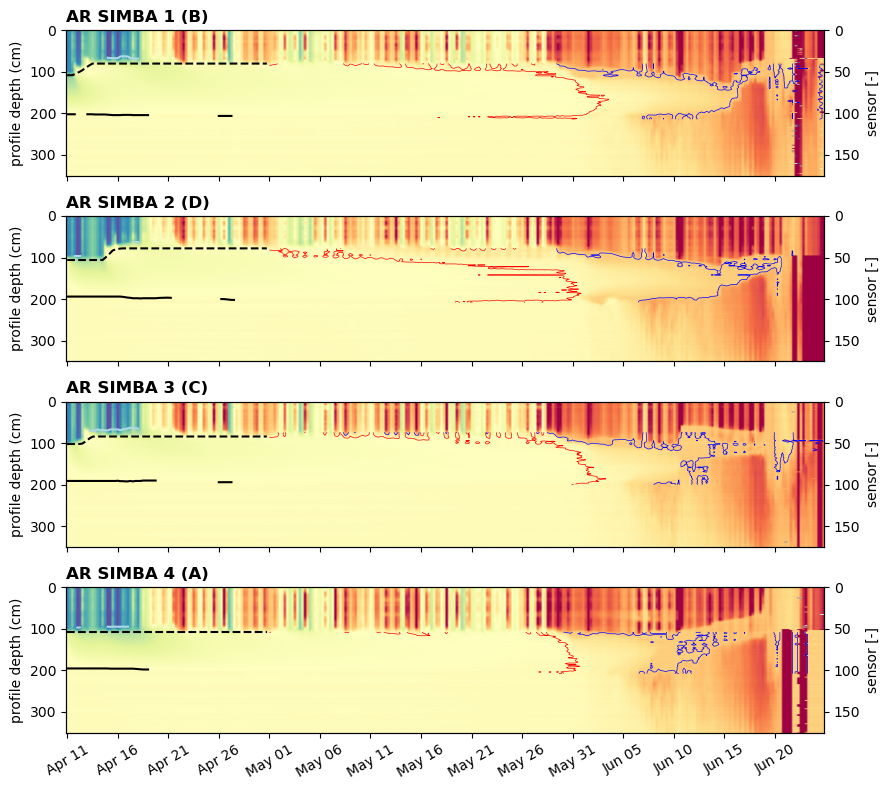

In [597]:
fig, axes = plt.subplots(4, 1, layout='tight', figsize=(9, 8))
norm = colors.TwoSlopeNorm(vmin=-20, vcenter=-2, vmax=5)
cmap = plt.get_cmap('Spectral_r')

# SIMBA A (R3)
f0 = axes[0].imshow(df1.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = df1.copy()
int_ice = int(np.nanmin(Z_is1))
int_ocn = int(np.nanmax(Z_io1)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:80] = np.nan
contourc.iloc[:Zice01] = np.nan
axes[0].contour(contourc.transpose(), levels = [-1.8, 0], colors = ['red', 'blue'], linewidths=0.5)
axes[0].plot(Z_as1[0:80], color = 'lightblue')
axes[0].plot(Z_is1[0:80], color = 'black', linestyle='dashed')
axes[0].plot(Z_io1[0:80], color = 'black')
axes[0].set_title('AR SIMBA 1 (B)', fontsize=12, fontweight='bold', loc='left')
axes[0].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'])
axes[0].set_xticks(np.arange(0, len(df1), 20), labels=[])
axes[0].set_ylim([175, 0])
axes[0].set_ylabel('profile depth (cm)', fontsize=10)

ax2 = axes[0].twinx()
ax2.set_yticks([0, 50, 100, 150])
ax2.set_ylabel('sensor [-]', fontsize=10)
ax2.set_ylim([175, 0])
# cb1 = plt.colorbar(f0, ax=axes[0], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
# cb1.set_label('$^o$C', fontsize=12)

# SIMBA B (R4)
f1 = axes[1].imshow(df2.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = df2.copy()
int_ice = int(np.nanmin(Z_is2))
int_ocn = int(np.nanmax(Z_io2)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:80] = np.nan
contourc.iloc[:Zice02] = np.nan
axes[1].contour(contourc.transpose(), levels = [-1.8, 0], colors = ['red', 'blue'], linewidths=0.5)
axes[1].plot(Z_as2[0:80], color = 'lightblue')
axes[1].plot(Z_is2[0:80], color = 'black', linestyle='dashed')
axes[1].plot(Z_io2[0:80], color = 'black')
axes[1].set_title('AR SIMBA 2 (D)', fontsize=12, fontweight='bold', loc='left')
axes[1].set_xticks(np.arange(0, len(df2), 20), labels=[])
axes[1].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'])
axes[1].set_ylim([175, 0])
axes[1].set_ylabel('profile depth (cm)', fontsize=10)

ax2 = axes[1].twinx()
ax2.set_yticks([0, 50, 100, 150])
ax2.set_ylabel('sensor [-]', fontsize=10)
ax2.set_ylim([175, 0])
# cb1 = plt.colorbar(f1, ax=axes[1], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
# cb1.set_label('$^o$C', fontsize=12)

# SIMBA C (R7)
f2 = axes[2].imshow(df3.transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = df3.copy()
int_ice = int(np.nanmin(Z_is3))
int_ocn = int(np.nanmax(Z_io3)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:80] = np.nan
contourc.iloc[:Zice03] = np.nan
axes[2].contour(contourc.transpose(), levels = [-1.8, 0], colors = ['red', 'blue'], linewidths=0.5)
axes[2].plot(Z_as3[0:80], color = 'lightblue')
axes[2].plot(Z_is3[0:80], color = 'black', linestyle='dashed')
axes[2].plot(Z_io3[0:80], color = 'black')
axes[2].set_title('AR SIMBA 3 (C)', fontsize=12, fontweight='bold', loc='left')
axes[2].set_xticks(np.arange(0, len(df3), 20), labels=[])
axes[2].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'])
axes[2].set_ylim([175, 0])
axes[2].set_ylabel('profile depth (cm)', fontsize=10)

ax2 = axes[2].twinx()
ax2.set_yticks([0, 50, 100, 150])
ax2.set_ylabel('sensor [-]', fontsize=10)
ax2.set_ylim([175, 0])
# cb2 = plt.colorbar(f2, ax=axes[2], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
# cb2.set_label('$^o$C', fontsize=12)

# SIMBA D (R7)
f3 = axes[3].imshow(df4.where(df4 > -100).transpose(), aspect='auto', cmap=cmap, norm=norm)
contourc = df4.copy()
int_ice = int(np.nanmin(Z_is4))
int_ocn = int(np.nanmax(Z_io4)) + 4
contourc.iloc[:, :int_ice] = np.nan
contourc.iloc[:, int_ocn:] = np.nan
contourc.iloc[:80] = np.nan
contourc.iloc[:Zice04] = np.nan
axes[3].contour(contourc.transpose(), levels = [-1.8, 0], colors = ['red', 'blue'], linewidths=0.5)
axes[3].plot(Z_as4[0:80], color = 'lightblue')
axes[3].plot(Z_is4[0:80], color = 'black', linestyle='dashed')
axes[3].plot(Z_io4[0:80], color = 'black')
axes[3].set_title('AR SIMBA 4 (A)', fontsize=12, fontweight='bold', loc='left')
axes[3].set_xticks(np.arange(0, len(df4), 20), labels = df4.index[::20].strftime('%b %d'), rotation=30)
axes[3].set_yticks([0, 50, 100, 150], labels=['0', '100', '200', '300'])
axes[3].set_ylim([175, 0])
axes[3].set_ylabel('profile depth (cm)', fontsize=10)

ax2 = axes[3].twinx()
ax2.set_yticks([0, 50, 100, 150])
ax2.set_ylabel('sensor [-]', fontsize=10)
ax2.set_ylim([175, 0])
# cb3 = plt.colorbar(f3, ax=axes[3], ticks=[-20, -10,  0, 5], pad=0.01, shrink=0.8)
# cb3.set_label('$^o$C', fontsize=12)


# plt.tight_layout()

fig.savefig('Svalbard_SIMBA_retrievals.png', dpi=300, bbox_inches='tight')

### Write Output

In [603]:
temp_profile1 = get_ice_temperature_profile(df1, Z_is1, Z_io1)
temp_profile2 = get_ice_temperature_profile(df2, Z_is2, Z_io2)
temp_profile3 = get_ice_temperature_profile(df3, Z_is3, Z_io3)
temp_profile4 = get_ice_temperature_profile(df4, Z_is4, Z_io4)

/var/folders/cn/mlxtkvc5149cqq3lmwvzcfrh0000gp/T/ipykernel_16076/1346670581.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ice_temp_profile = data.values[k, int(Zis[k]):int(Zio[k])]


In [604]:
check1 = write_retrieval_output('Svalbard_SIMBA1', hi1, hs1, temp_profile1, df1.index, [77.8812, 16.7794])
check2 = write_retrieval_output('Svalbard_SIMBA2', hi2, hs2, temp_profile2, df2.index, [77.8790, 16.7887])
check3 = write_retrieval_output('Svalbard_SIMBA3', hi3, hs3, temp_profile3, df3.index, [77.8800, 16.7794])
check4 = write_retrieval_output('Svalbard_SIMBA4', hi4, hs4, temp_profile4, df4.index, [77.8790, 16.7887])